# MTSamples dataset EDA

In [30]:
import pandas as pd

# This loads the dataset from Hugging Face's datasets library using pandas.
df = pd.read_csv("hf://datasets/harishnair04/mtsamples/mtsamples.csv")

In [31]:
print(df.info())
print(df.isna().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4999 entries, 0 to 4998
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Unnamed: 0         4999 non-null   int64 
 1   description        4999 non-null   object
 2   medical_specialty  4999 non-null   object
 3   sample_name        4999 non-null   object
 4   transcription      4966 non-null   object
 5   keywords           3931 non-null   object
dtypes: int64(1), object(5)
memory usage: 234.5+ KB
None
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [32]:
df.head()

,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [33]:
# Top medical_specialty
print(df["medical_specialty"].value_counts())

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Urology                           158
Discharge Summary                 108
ENT - Otolaryngology               98
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    62
Psychiatry / Psychology            53
Office Notes                       51
Podiatry                           47
Dermatology                        29
Cosmetic / Plastic Surgery         27
Dentistry                       

### Clean some columns in the dataset

In [34]:
# Some keywords rows have a disclaimer with this form: 
# "NOTE,: Thesetranscribed medical {column} sample reports and examples are provided by various users andare for reference purpose only. MTHelpLine does not certify accuracy and quality of sample reports.These transcribed medical transcription sample reports may include some uncommon or unusual formats;this would be due to the preference of the dictating physician. All names and dates have beenchanged (or removed) to keep confidentiality. Any resemblance of any type of name or date orplace or anything else to real world is purely incidental."

# We need to remove this disclaimer from the keywords column, as it is not relevant for our analysis and may introduce noise in our models.
disclaimer = """NOTE,: Thesetranscribed medical transcription sample reports and examples are provided by various users andare for reference purpose only. MTHelpLine does not certify accuracy and quality of sample reports.These transcribed medical transcription sample reports may include some uncommon or unusual formats;this would be due to the preference of the dictating physician. All names and dates have beenchanged (or removed) to keep confidentiality. Any resemblance of any type of name or date orplace or anything else to real world is purely incidental."""

counter = 0
for i in range(len(df)):
    if not pd.isna(df.loc[i, "keywords"]) and disclaimer in df.loc[i, "keywords"]:
        counter += 1
        df.loc[i, "keywords"] = df.loc[i, "keywords"].replace(disclaimer, "").strip()

print(f"Disclaimer found in {counter} rows. Disclaimer removed from these rows.")

Disclaimer found in 253 rows. Disclaimer removed from these rows.


count    4999.000000
mean       18.499700
std        11.994595
min         0.000000
25%         9.000000
50%        16.000000
75%        25.500000
max        76.000000
Name: description_length, dtype: float64
count    4999.000000
mean       16.830166
std        12.005108
min         0.000000
25%         8.000000
50%        17.000000
75%        24.000000
max        79.000000
Name: keywords_length, dtype: float64
count    4999.000000
mean      462.382877
std       317.575604
min         1.000000
25%       239.000000
50%       397.000000
75%       614.000000
max      3029.000000
Name: transcription_length, dtype: float64


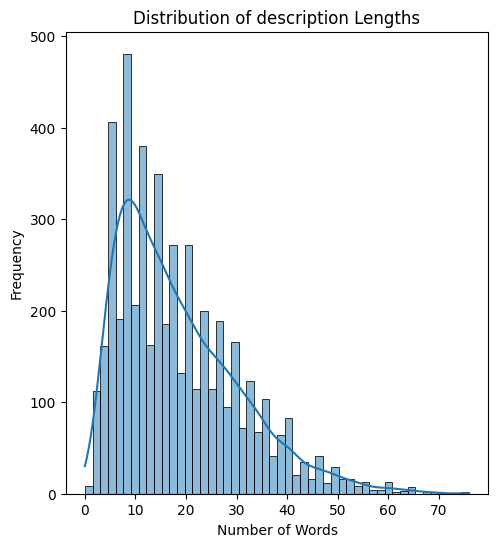

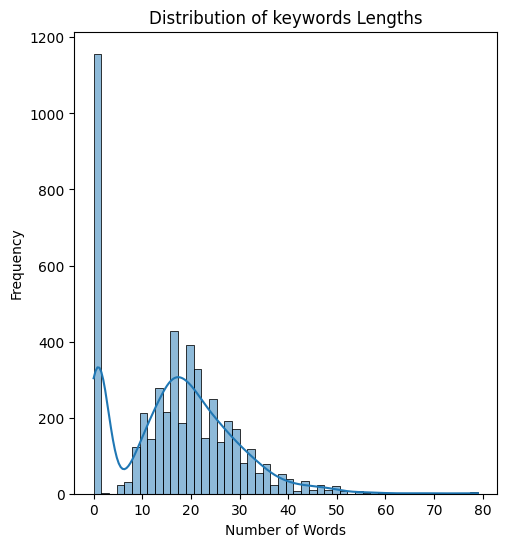

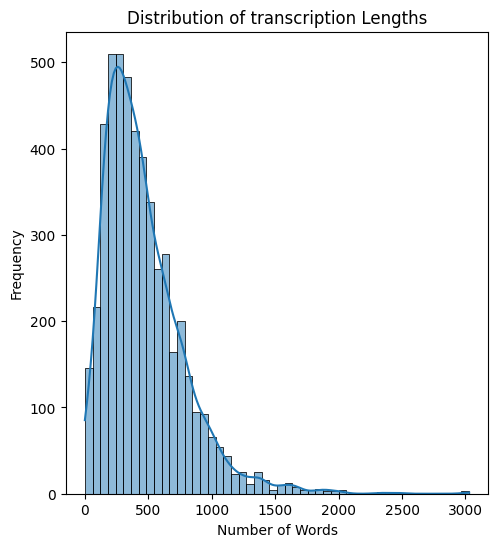

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the distribution of the transcription lengths to understand the typical length of the inputs we will be working with. This can help us decide on appropriate model architectures and training strategies.
def length_distribution(df: pd.DataFrame, column: str):
    df[f"{column}_length"] = df[column].apply(lambda x: len(str(x).split()))
    print(df[f"{column}_length"].describe())

    # Visualize the distribution of transcription lengths using a histogram and a boxplot to identify any potential outliers or skewness in the data.
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(df[f"{column}_length"], bins=50, kde=True)
    plt.title(f"Distribution of {column} Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")

for column in ["description", "keywords", "transcription"]:
    length_distribution(df, column)

**Some insights**
- There are keywords that has length 0, which we cannot treat as valid. We will have to set a minimum length to 7 since the min keyword from a record is "surgery" which has 7 chars
- In some keywords there were a disclaimer string that must be removed.
- Like keywords, description also has records that are length 0, the minimum length for this dataset is 14 chars. We will need to take it into account.
- There are transcriptions that are too short to count them as valid. We will need to set a minimum length to avoid incorrect samples.

### MTSamples → Alpaca Format: The Schema Mapping

MTSamples has these columns: `description`, `medical_specialty`, `sample_name`, `transcription`, `keywords`.

The Alpaca dataset format uses three columns — `instruction`, `input`, and `output` — which are merged into a single prompt for supervised instruction fine-tuning.

This MTSamples records map to multiple task types → Construct several distinct tasks per record, which multiplies ~4,500 usable records into a richer dataset:

```text
Task 1 — Summarization:
  instruction: "Summarize the following clinical transcription into a concise description."
  input:       transcription
  output:      description       ← already in the dataset

Task 2 — Specialty Classification:
  instruction: "Identify the medical specialty of the following clinical note."
  input:       transcription
  output:      medical_specialty  ← already in the dataset

Task 3 — Keyword Extraction:
  instruction: "Extract the key medical terms and clinical concepts from this transcription."
  input:       transcription
  output:      keywords           ← already in the dataset

Task 4 — RAG-Augmented Response (most thesis-critical):
  instruction: "You are a clinical assistant. Using the patient note and the retrieved medical evidence below, provide a clinically grounded assessment."
  input:       transcription + [PubMed context block]
  output:      description (or synthetically generated answer)

````

Task 4 is what trains the model to consume RAG context. Without examples of this format during fine-tuning, the model at inference time will not reliably integrate retrieved PubMed passages into its output.


In [24]:
ALPACA_PROMPT = """Below is a clinical instruction paired with relevant input. \
Write a response appropriate for a clinical AI assistant.

### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

SYSTEM_PROMPT = (
    "You are a clinical AI assistant trained to support evidence-based medicine. "
    "When provided with retrieved medical literature, integrate it into your reasoning."
)

EOS_TOKEN = "<|eot_id|>" # Must add EOS_TOKEN

In [46]:
def format_alpaca(examples: dict) -> dict:
    instructions = examples["instruction"]
    inputs       = examples["input"]
    outputs      = examples["output"]
    texts = []
    for instruction, inp, output in zip(instructions, inputs, outputs):
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        text = ALPACA_PROMPT.format(
            instruction=instruction,
            input=inp,
            output=output,
        ) + "<|eot_id|>"  # Llama-3 EOS token
        texts.append(text)
    return {"text": texts}

In [38]:
def build_summarization_example(row: pd.Series) -> dict | None:
    """Transcription → description. The cleanest 1:1 mapping in MTSamples."""
    transcription = str(row.get("transcription", "")).strip()
    description = str(row.get("description", "")).strip()
    # Check if there is a minimum amount of text in both transcription and description to ensure quality of the example. These thresholds can be adjusted based on the distribution of lengths in the dataset.
    if len(transcription) < 100 or len(description) < 20:
        return None
    return {
        "instruction": "Summarize the following clinical transcription into a concise description.",
        "input": transcription,
        "output": description,
        "task_type": "summarization",
        "medical_specialty": row.get("medical_specialty", ""),
    }

In [39]:
def build_specialty_classification_example(row: pd.Series) -> dict | None:
    """Transcription → specialty label."""
    transcription = str(row.get("transcription", "")).strip()
    specialty = str(row.get("medical_specialty", "")).strip()
    if len(transcription) < 100 or not specialty:
        return None
    return {
        "instruction": "Identify the medical specialty of the following clinical note.",
        "input": transcription,
        "output": specialty,
        "task_type": "classification",
        "medical_specialty": specialty,
    }

In [40]:
def build_keyword_extraction_example(row: pd.Series) -> dict | None:
    """Transcription → keywords."""
    transcription = str(row.get("transcription", "")).strip()
    keywords = str(row.get("keywords", "")).strip()
    if len(transcription) < 100 or not keywords or keywords.lower() in ("", "nan"):
        return None
    return {
        "instruction": (
            "Extract the key medical terms, diagnoses, procedures, and clinical concepts "
            "from the following transcription."
        ),
        "input": transcription,
        "output": keywords,
        "task_type": "keyword_extraction",
        "medical_specialty": row.get("medical_specialty", ""),
    }

In [ ]:
def build_rag_augmented_example(
    row: pd.Series,
    pubmed_context: str,
) -> dict | None:
    """
    RAG-aware training example.
    At training time, pubmed_context is pre-retrieved for each specialty/keyword cluster.
    At inference time, this is replaced by live Qdrant retrieval.
    """
    transcription = str(row.get("transcription", "")).strip()
    description = str(row.get("description", "")).strip()
    if len(transcription) < 100 or len(description) < 20 or not pubmed_context:
        return None

    rag_input = (
        f"PATIENT NOTE:\n{transcription}\n\n"
        f"RETRIEVED MEDICAL EVIDENCE:\n{pubmed_context}"
    )
    return {
        "instruction": (
            "You are a clinical assistant. Using the patient note and the retrieved "
            "medical evidence below, provide a clinically grounded summary and assessment."
        ),
        "input": rag_input,
        "output": description,
        "task_type": "rag_augmented",
        "medical_specialty": row.get("medical_specialty", ""),
    }

### Build the entire dataset from MTSamples

In [43]:
from datasets import Dataset, DatasetDict

def build_dataset(
    mtsamples_path: str = "hf://datasets/harishnair04/mtsamples/mtsamples.csv",
    pubmed_contexts: dict = None,   # dict[specialty -> pubmed_abstract_string]
    train_ratio: float = 0.8,
    val_ratio: float = 0.1,
    # test_ratio: implicitly 0.1 — held out for 4-config evaluation
    seed: int = 42,
    include_rag_examples: bool = True,
) -> DatasetDict:

    df = pd.read_csv(mtsamples_path)
    # Drop rows with no transcription
    #df = df.dropna(subset=["transcription"])
    #df = df[df["transcription"].str.len() > 100].reset_index(drop=True)

    examples = []

    for _, row in df.iterrows():
        # Task 1: Summarization
        ex = build_summarization_example(row)
        if ex:
            examples.append(ex)

        # Task 2: Specialty classification
        ex = build_specialty_classification_example(row)
        if ex:
            examples.append(ex)

        # Task 3: Keyword extraction
        ex = build_keyword_extraction_example(row)
        if ex:
            examples.append(ex)

        # Task 4: RAG-augmented (only if pre-retrieved contexts are available)
        if include_rag_examples and pubmed_contexts:
            specialty = str(row.get("medical_specialty", "")).strip()
            context = pubmed_contexts.get(specialty, "")
            if context:
                ex = build_rag_augmented_example(row, context)
                if ex:
                    examples.append(ex)

    dataset = Dataset.from_list(examples).shuffle(seed=seed)

    # Train / val / test split
    n = len(dataset)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)

    return DatasetDict({
        "train": dataset.select(range(n_train)),
        "validation": dataset.select(range(n_train, n_train + n_val)),
        "test": dataset.select(range(n_train + n_val, n)),  # held-out for evaluation
    })

In [45]:
splits = build_dataset(include_rag_examples=False)
splits["test"][0]

{'instruction': 'Extract the key medical terms, diagnoses, procedures, and clinical concepts from the following transcription.',
 'input': 'SUBJECTIVE: , The patient is admitted for shortness of breath, continues to do fairly well.  The patient has chronic atrial fibrillation, on anticoagulation, INR of 1.72.  The patient did undergo echocardiogram, which shows aortic stenosis, severe.  The patient does have an outside cardiologist.  I understand she was scheduled to undergo workup in this regard.,PHYSICAL EXAMINATION,VITAL SIGNS:  Pulse of 78 and blood pressure 130/60.,LUNGS:  Clear.,HEART:  A soft systolic murmur in the aortic area.,ABDOMEN:  Soft and nontender.,EXTREMITIES:  No edema.,IMPRESSION:,1.  Status shortness of breath responding well to medical management.,2.  Atrial fibrillation, chronic, on anticoagulation.,3.  Aortic stenosis.,RECOMMENDATIONS:,1.  Continue medications as above.,2.  The patient would like to follow with her cardiologist regarding aortic stenosis.  She may

In [ ]:
train_ds = splits["train"].map(format_alpaca, batched=True)
train_ds[0]

Map:   0%|          | 0/10868 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'input', 'output', 'task_type', 'medical_specialty', 'text'],
    num_rows: 10868
})